# 04 – Modeling & Model Evaluation

This notebook covers the modeling phase of the Telco Customer Churn project.

**Goals of this notebook:**
- Train baseline classification models
- Evaluate performance using multiple metrics
- Compare Logistic Regression, Random Forest, and XGBoost
- Improve XGBoost using hyperparameter optimization with Optuna
- Visualize ROC Curve and Confusion Matrix


## 1. Load Cleaned Dataset & Prepare Train/Test Split

We start by loading the cleaned dataset created during feature engineering, separating features and labels, and performing a train/test split with stratification.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/processed/cleaned_telco.csv")

In [3]:
X = df.drop("Churn", axis=1)
y = (df["Churn"] == "Yes").astype(int)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## 2. Baseline Model 1 — Logistic Regression (Balanced)

We begin with Logistic Regression as a classical linear baseline model.

- `class_weight='balanced'` helps address class imbalance (26% churn rate).
- We evaluate Accuracy, Precision, Recall, F1, and ROC AUC.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [6]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000)

In [7]:
lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [8]:
y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

In [9]:
metrics_lr = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision_Pos(Churn)": precision_score(y_test,y_pred),
    "Recall_Pos(Churn)": recall_score(y_test, y_pred),
    "F1_Pos(Churn)": f1_score(y_test,y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_proba)
}
metrics_lr

{'Accuracy': 0.7381121362668559,
 'Precision_Pos(Churn)': 0.504302925989673,
 'Recall_Pos(Churn)': 0.7834224598930482,
 'F1_Pos(Churn)': 0.6136125654450262,
 'ROC_AUC': 0.8414218915497688}

## 3. Baseline Model 2 — Random Forest (Balanced)

Random Forest is a tree-based ensemble model well-suited for nonlinear patterns.

Key notes:
- `class_weight='balanced'` compensates for minority churn class
- `n_estimators=400` provides stable performance
- Good at capturing interactions between categorical-encoded features


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [11]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)

In [12]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [13]:
metrics_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision_Pos(Churn)": precision_score(y_test, y_pred_rf),
    "Recall_Pos(Churn)": recall_score(y_test, y_pred_rf),
    "F1_Pos(Churn)": f1_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_proba_rf)
}
metrics_rf

{'Accuracy': 0.7863733144073811,
 'Precision_Pos(Churn)': 0.6237288135593221,
 'Recall_Pos(Churn)': 0.4919786096256685,
 'F1_Pos(Churn)': 0.5500747384155455,
 'ROC_AUC': 0.8234041179053967}

## 4. Baseline Model 3 — XGBoost (scale_pos_weight)

XGBoost is a gradient boosting algorithm that usually performs well on structured datasets.

Key settings:
- `scale_pos_weight = (1-pos)/pos` to counter class imbalance
- `tree_method='hist'` to speed up training
- `learning_rate=0.05` and `max_depth=5` for stable baseline performance

In [14]:
X_train_np = X_train.astype("float32").values
X_test_np  = X_test.astype("float32").values
y_train_np = y_train.values
y_test_np  = y_test.values

from xgboost import XGBClassifier
pos = y_train_np.mean()
spw = (1 - pos) / pos

xgb = XGBClassifier(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    scale_pos_weight=spw,
    tree_method="hist",
)

xgb.fit(X_train_np, y_train_np)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

metrics_xgb = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision_Pos(Churn)": precision_score(y_test, y_pred_xgb),
    "Recall_Pos(Churn)": recall_score(y_test, y_pred_xgb),
    "F1_Pos(Churn)": f1_score(y_test, y_pred_xgb),
    "ROC_AUC": roc_auc_score(y_test, y_proba_xgb)
}
metrics_xgb

{'Accuracy': 0.7537260468417317,
 'Precision_Pos(Churn)': 0.5267326732673268,
 'Recall_Pos(Churn)': 0.7112299465240641,
 'F1_Pos(Churn)': 0.6052332195676906,
 'ROC_AUC': 0.8313144230024024}

## 5. Baseline Model Comparison

We compare all baseline models (LR, RF, XGB) using key metrics:
- **Accuracy**: overall correctness
- **Precision (Churn)**: how many predicted churns were actually correct
- **Recall (Churn)**: how many actual churns we successfully detected
- **ROC AUC**: how well the model separates churn vs non-churn

Higher ROC AUC indicates better ranking ability.

In [15]:

rows = [("LR(balanced)", metrics_lr),
        ("RF(balanced)", metrics_rf)]
try:
    rows.append(("XGB(spw)", metrics_xgb))
except NameError:
    pass

results = pd.DataFrame([{**m, "Model": n} for n,m in rows]).set_index("Model").round(4)
results.sort_values("ROC_AUC", ascending=False)


,Accuracy,Precision_Pos(Churn),Recall_Pos(Churn),F1_Pos(Churn),ROC_AUC
Model,,,,,
LR(balanced),0.7381,0.5043,0.7834,0.6136,0.8414
XGB(spw),0.7537,0.5267,0.7112,0.6052,0.8313
RF(balanced),0.7864,0.6237,0.4920,0.5501,0.8234


## 6. ROC Curve for Baseline XGBoost

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate.  
A higher curve indicates a more discriminative model.  
We also compute the AUC score for quantitative comparison.

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
fpr, tpr, thresholds = roc_curve(y_test,y_proba_xgb)
roc_auc = auc(fpr, tpr)

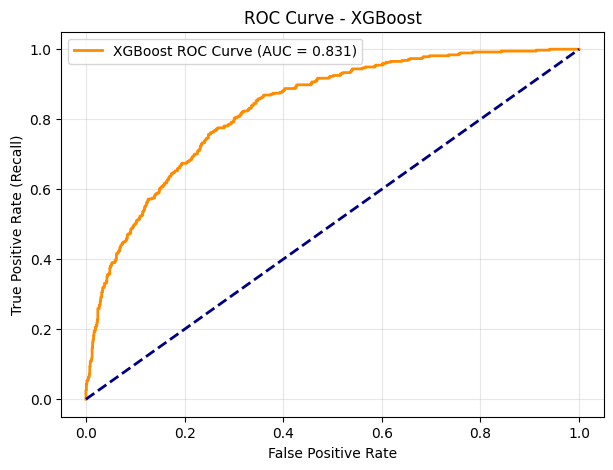

In [18]:
plt.figure(figsize = (7,5))
plt.plot(fpr,tpr, color = "darkorange", lw=2,
        label = f"XGBoost ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Confusion Matrix – XGBoost

The confusion matrix helps understand:
- True Negatives (correctly predicted non-churn)
- False Positives (predicted churn but actually not)
- False Negatives (missed actual churns)
- True Positives (correctly predicted churns)

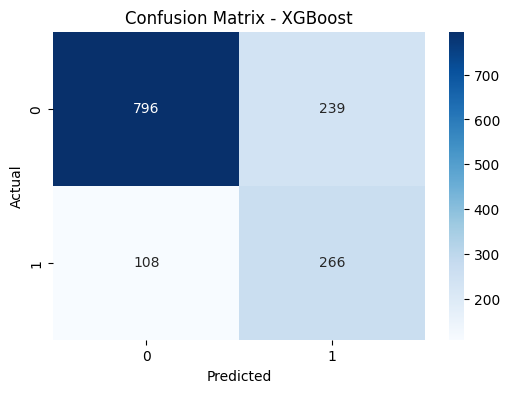

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize = (6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

## 8. XGBoost Hyperparameter Tuning with Optuna

To improve performance, we optimize XGBoost using Optuna.

Why Optuna?
- Efficient search compared to Grid/Random Search
- Automates hyperparameter exploration
- Can maximize any evaluation metric (we use ROC AUC)

We tune:
- n_estimators
- max_depth
- learning_rate
- subsample
- colsample_bytree
- gamma
- min_child_weight

Goal: **maximize ROC AUC via stratified cross-validation**.


In [20]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),

        "random_state": 42,
        "eval_metric": "logloss",
        "tree_method": "hist",
        "scale_pos_weight": spw,
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = cross_val_score(
        model,
        X_train_np,
        y_train_np,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return auc_scores.mean()


In [21]:
study = optuna.create_study(
    direction="maximize",
    study_name="xgb_churn_optimization"
)

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best ROC AUC:", study.best_trial.value)
print("Best params:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")


[I 2025-11-28 14:04:28,327] A new study created in memory with name: xgb_churn_optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-28 14:04:29,417] Trial 0 finished with value: 0.8447644979753636 and parameters: {'n_estimators': 441, 'max_depth': 4, 'learning_rate': 0.07039669376106951, 'subsample': 0.7495917820190343, 'colsample_bytree': 0.8255078671804849, 'min_child_weight': 4.556763561353451, 'gamma': 3.6159989255789}. Best is trial 0 with value: 0.8447644979753636.
[I 2025-11-28 14:04:30,082] Trial 1 finished with value: 0.8456738701812311 and parameters: {'n_estimators': 295, 'max_depth': 5, 'learning_rate': 0.052144948179891584, 'subsample': 0.8313190885156392, 'colsample_bytree': 0.7035245799618303, 'min_child_weight': 1.8736229974006795, 'gamma': 3.1523460434200707}. Best is trial 1 with value: 0.8456738701812311.
[I 2025-11-28 14:04:30,160] Trial 2 finished with value: 0.8499905354760782 and parameters: {'n_estimators': 266, 'max_depth': 3, 'learning_rate': 0.023026914552966158, 'subsample': 0.853631918895039, 'colsample_bytree': 0.6481295314774052, 'min_child_weight': 3.0177581609455326, 'gam

## 9. Evaluate Tuned XGBoost Model

After finding the best hyperparameters,  
we retrain XGBoost using the optimized settings and evaluate performance on the test set.

We compare tuned XGBoost to baseline models.

In [22]:
best_params = study.best_trial.params.copy()

best_params.update({
    "random_state": 42,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "scale_pos_weight": spw,
    "n_jobs": -1,
})

best_xgb = XGBClassifier(**best_params)
best_xgb.fit(X_train_np, y_train_np)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_best = best_xgb.predict(X_test_np)
y_proba_best = best_xgb.predict_proba(X_test_np)[:, 1]

metrics_xgb_tuned = {
    "Accuracy": accuracy_score(y_test_np, y_pred_best),
    "Precision_Pos(Churn)": precision_score(y_test_np, y_pred_best),
    "Recall_Pos(Churn)": recall_score(y_test_np, y_pred_best),
    "F1_Pos(Churn)": f1_score(y_test_np, y_pred_best),
    "ROC_AUC": roc_auc_score(y_test_np, y_proba_best),
}

metrics_xgb_tuned


{'Accuracy': 0.7466288147622427,
 'Precision_Pos(Churn)': 0.5145299145299145,
 'Recall_Pos(Churn)': 0.8048128342245989,
 'F1_Pos(Churn)': 0.6277372262773723,
 'ROC_AUC': 0.8470136144049188}

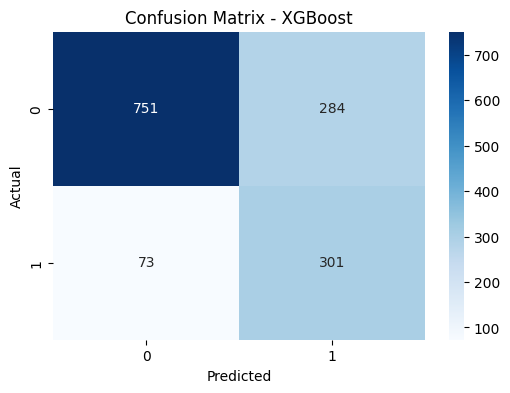

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_np, y_pred_best)

plt.figure(figsize = (6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

We optimized the model for high recall to avoid missing churn customers, which naturally results in lower precision. This is acceptable for churn use-cases where false negatives are more costly than false positives.

## 10. Final Model Comparison

We compare Logistic Regression, Random Forest, and Tuned XGBoost side-by-side.


In [24]:
rows = [
    ("LR(balanced)", metrics_lr),
    ("RF(balanced)", metrics_rf),
    ("XGB(tuned)", metrics_xgb_tuned)
]

results = pd.DataFrame([{**m, "Model": n} for n,m in rows]).set_index("Model").round(4)

results.sort_values("ROC_AUC",ascending=False)

,Accuracy,Precision_Pos(Churn),Recall_Pos(Churn),F1_Pos(Churn),ROC_AUC
Model,,,,,
XGB(tuned),0.7466,0.5145,0.8048,0.6277,0.8470
LR(balanced),0.7381,0.5043,0.7834,0.6136,0.8414
RF(balanced),0.7864,0.6237,0.4920,0.5501,0.8234



**Tuned XGBoost achieves the highest ROC AUC**,  
making it the best candidate for further interpretation and business decision-making.


In [25]:
import joblib
joblib.dump(best_xgb, "../models/best_xgb_model.pkl")

['../models/best_xgb_model.pkl']